In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.patches import Rectangle
from datetime import datetime 
from OceanDataStore import OceanDataCatalog
import dask

In [2]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [3]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [4]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [5]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T5d_3d']

In [6]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

computed


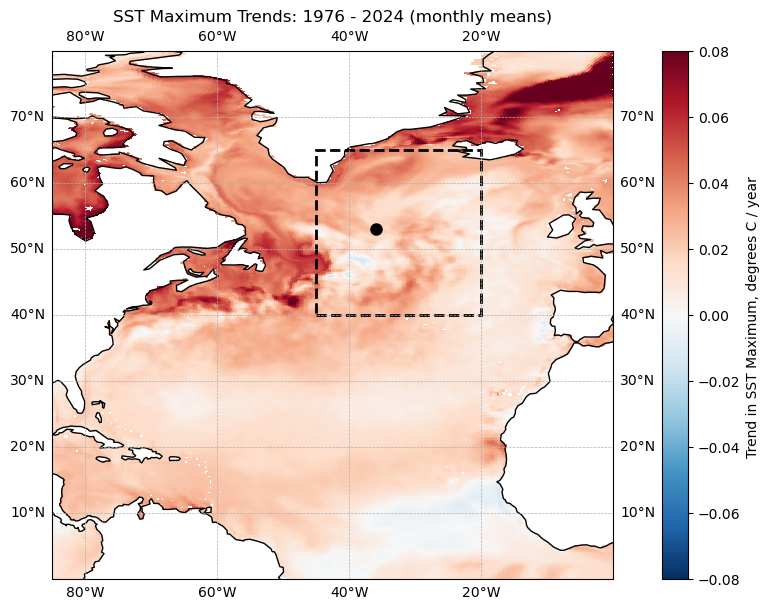

In [8]:
## Using monthly means, from 1976

ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12', 
                          bbox = (-85.0, 0.0, 0.0, 80.0))
septembers = []
for year in range (1976, 2025):
    septembers.append(f'{year}-09-15')

september_data = (ds1['tos_con'].sel(time_counter=septembers, method='nearest')).compute()
september_data['time_counter'] = september_data['time_counter'].dt.year
print('computed')

ny, nx = september_data.sizes['y'], september_data.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = september_data.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['time_counter'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": september_data['y'],
        "x": september_data['x'],
        "nav_lat": (("y", "x"), september_data['nav_lat'].values),
        "nav_lon": (("y", "x"), september_data['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST Maximum"})

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST Maximum, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Maximum Trends: 1976 - 2024 (monthly means)')  
plt.savefig('Maximums_1976_2024_monthlymeans.jpg') 

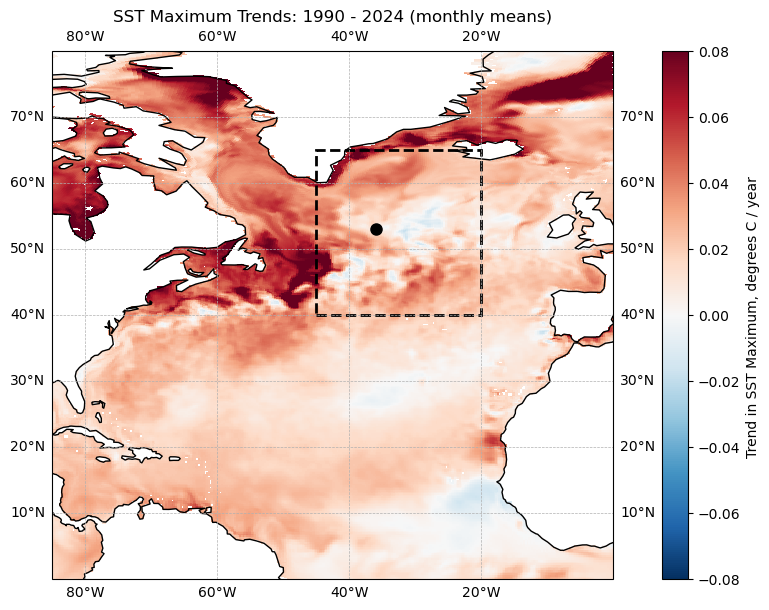

In [10]:
## Using Monthly means, from 1990

september_data_subset = september_data.sel(time_counter = slice(1990, 2024))

ny, nx = september_data_subset.sizes['y'], september_data_subset.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = september_data_subset.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['time_counter'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": september_data_subset['y'],
        "x": september_data_subset['x'],
        "nav_lat": (("y", "x"), september_data_subset['nav_lat'].values),
        "nav_lon": (("y", "x"), september_data_subset['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST Maximum"})

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST Maximum, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Maximum Trends: 1990 - 2024 (monthly means)')  
plt.savefig('Maximums_1990_2024_monthlymeans.jpg') 

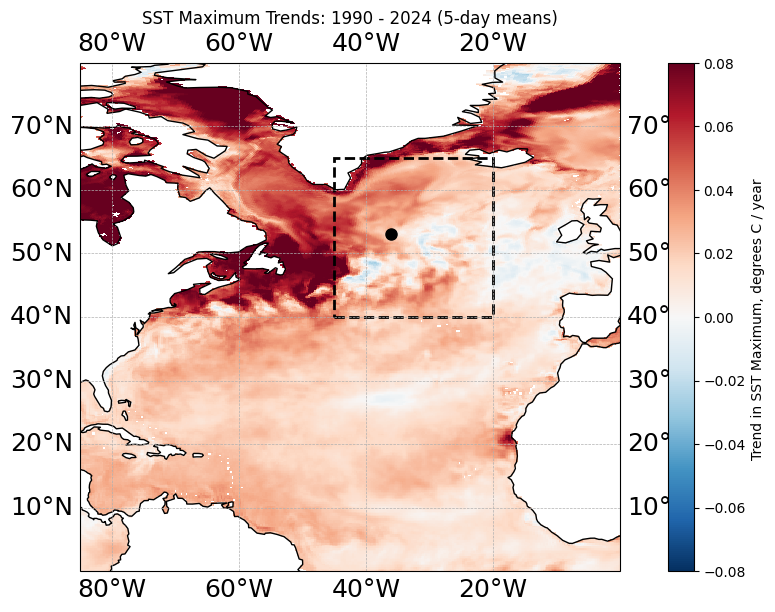

In [7]:
## Using 5-day means, from 1990

ds2 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12', 
                          bbox = (-85.0, 0.0, 0.0, 80.0))

max_region = ds2.sel(time_counter = ds2['time_counter'].dt.month.isin([8, 9, 10]))
grouped = max_region['tos_con'].groupby('time_counter.year')
max_temp = (grouped.max(dim='time_counter')).compute()

ny, nx = max_temp.sizes['y'], max_temp.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = max_temp.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['year'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": max_temp['y'],
        "x": max_temp['x'],
        "nav_lat": (("y", "x"), max_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), max_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST Maximum"})

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'fontsize': 18}
gl.ylabel_style = {'fontsize': 18}
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST Maximum, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Maximum Trends: 1990 - 2024 (5-day means)')  
plt.savefig('Maximums_1990_2024_5daymeans.jpg') 